# **Librerias y Funciones**

In [ ]:
#Instalación de la libreria que usaremos para calcular homología persistente via Vietoris-Rips
!pip install ripser

In [ ]:
#Importamos todas las librerias necesarias
import numpy as np
import matplotlib.pyplot as plt
import bisect
import math

from ripser import ripser
from persim import plot_diagrams
from persim import PersistenceImager

from mpl_toolkits  import  mplot3d

from scipy.cluster.hierarchy import dendrogram, linkage, set_link_color_palette

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
from sklearn.datasets import make_blobs

In [ ]:
#Funcion para aplicar el embedding de Takens
def takens_embedding(signal, tau, d):
     n = len(signal) - (d-1)*tau
     embedded = np.zeros((n, d))

     for i in range(0,d):
         embedded[:, i] = signal[i*tau : i*tau + n]
     return embedded

#Funcion para calcular Landscapes
def persistence_landscape(diag):
    diag.sort(key=lambda x: (x[0], -x[1]))

    L = []
    k = 0

    while len(diag) > 0:
        Lk = []
        b, d = diag.pop(0)

        Lk.extend([(float('-inf'), 0), (b, 0), ((b + d) / 2, (d - b) / 2)])


        while Lk[-1] != (float('inf'), 0):

            if not diag or d >= max((item[1] for item in diag), default=-float('inf')):
                Lk.extend([(d, 0), (float('inf'), 0)])
            else:

                idx_prime = -1
                for i, (bp, dp) in enumerate(diag):
                    if dp > d:
                        idx_prime = i
                        break

                b_prime, d_prime = diag.pop(idx_prime)

                if b_prime > d:
                    Lk.append((d, 0))

                if b_prime >= d:
                    Lk.append((b_prime, 0))
                else:
                    Lk.append(((b_prime + d) / 2, (d - b_prime) / 2))

                    new_item = (b_prime, d)

                    bisect.insort(diag, new_item, key=lambda x: (x[0], -x[1]))

                Lk.append(((b_prime + d_prime) / 2, (d_prime - b_prime) / 2))
                b, d = b_prime, d_prime

        L.append(Lk)
        k += 1

    return L

#Funcion para graficar el diagrama de persistencia
def graficar_diag(dgms, Titulo, guardado):
    fig, ax = plt.subplots(figsize=(7, 7))

    max_val = max([np.nanmax(d[np.isfinite(d)]) for d in dgms if d.size > 0]) * 1.1
    ax.plot([0, max_val], [0, max_val], '--', color='black', alpha=1)

    x_vals = np.linspace(0, max_val, 100)
    ax.fill_between(x_vals, 0, x_vals, color='lightgray', alpha=0.8)

    colors = ['#2AA58B', '#804C80', '#27ae60', '#c0392b']
    labels = ['$H_0$', '$H_1$', '$H_2$', '$H_3$']

    for i, dgm in enumerate(dgms):
        if dgm.size > 0:
            clean_dgm = dgm[np.isfinite(dgm).all(axis=1)]

            ax.scatter(clean_dgm[:, 0], clean_dgm[:, 1],
                      color=colors[i],
                      label=labels[i],
                      s=80,
                      alpha=0.8,
                      edgecolors='none')

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_xlim(-0.03*max_val, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel('Nacimiento', fontsize=15)
    ax.set_ylabel('Muerte', fontsize=15)
    ax.set_title(f'{Titulo}', fontsize=15)
    ax.legend()
    plt.savefig(f'{guardado}', bbox_inches='tight')
    plt.show()


# **Importe de los Datos y Calculo de sus Diagramas de Persistencia**

In [ ]:
#Algebraicos
raiz_dos='414213562373095048801688724209698078569671875376948073176679737990732478462107038850387534327641572735013846230912297024924836055850737212644121497099935831413222665927505592755799950501152782060571470109559971605970273453456862027207854062129874579464685317993433470576322673900714657370791736519366722124251570496083045922861799941014254270489789236514233321135364698544327852394587922244651897538272178513179579514711577725032875928123540651830465121679537541659052840315525040934474934087626623557906306088262994501851802418442914079491212380301935257676326774167640393864457530145648189854550143541214931132220717295028757984721739640495942642361114251100097415057654398459345547542466853214610'

raiz_tres='732050807568877293527446341505872366942805253810380628055806979451933016908800037081146186757248575675626141415406703029969945094998952478811655512094373648528093231902305582067974820101084674923265015312343266903322886650672254668921837971227046691699364038602416514080632898595561176172138988617307849741134956650873731277227571261522858632013268721606664341892203404307105821668511843027837866837116973065185642444444483721732891231295873470875753969785263324533831941350562495326514572017762024853633797131629981030853675254861163094711299417828233104669903992744726362989765243972716968314429853914409396038722927933336517681137053857235082374892956351291888433479044314964531328179348624467119'

raiz_cinco='236067977499789696409173668731276235440618359611525724270897245410520925637804899414414408378782274969508176150773783504232567724470738963863589476568955106445625523274819461571407876463431396402571550704366455316557998345144590614118590663844081549996623758739554801819575672859524154599467575028918837679416379782273290790002860727158912237171673407513236144953806773525512140657545969548164893314216157113813069585444163321127436457076145107511357228422519753166446496386622688881895612587239547322412549513656579637603994316398216220106268084657046916716179704510997891532693222185307489776631009612376406244853613676242465711363964608106065157613920423176743419967789132399155895299354142218036'

phi='618033988749894848204586834365638117720309179805762862135448622705260462818902449707207204189391137484754088075386891752126633862223536931793180060766726354433389086595939582905638322661319928290267880675208766892501711696207032221043216269548626296313614438149758701220340805887954454749246185695364864449241044320771344947049565846788509874339442212544877066478091588460749988712400765217057517978834166256249407589069704000281210427621771117778053153171410117046665991466979873176135600670874807101317952368942752194843530567830022878569978297783478458782289110976250030269615617002504643382437764861028383126833037242926752631165339247316711121158818638513316203840052221657912866752946549068113171599343235973494985090409476213222981017261070596116456299098162905552085247903524060'

#Trascendentes
pi='141592653589793238462643383279502884197169399375105820974944592307816406286208998628034825342117067982148086513282306647093844609550582231725359408128481117450284102701938521105559644622948954930381964428810975665933446128475648233786783165271201909145648566923460348610454326648213393607260249141273724587006606315588174881520920962829254091715364367892590360011330530548820466521384146951941511609433057270365759591953092186117381932611793105118548074462379962749567351885752724891227938183011949129833673362440656643086021394946395224737190702179860943702770539217176293176752384674818467669405132000568127145263560827785771342757789609173637178721468440901224953430146549585371050792279689258923542019956112129021960864034418159813629774771309960518707211349999998372978049'

e='71828182845904523536028747135266249775724709369995957496696762772407663035354759457138217852516642742746639193200305992181741359662904357290033429526059563073813232862794349076323382988075319525101901157383418793070215408914993488416750924476146066808226480016847741185374234544243710753907774499206955170276183860626133138458300075204493382656029760673711320070932870912744374704723069697720931014169283681902551510865746377211125238978442505695369677078544996996794686445490598793163688923009879312773617821542499922957635148220826989519366803318252886939849646510582093923982948879332036250944311730123819706841614039701983767932068328237646480429531180232878250981945581530175671736133206981125099618188159304169035159888851934580727386673858942287922849989208680582574927961048419844'

Champernowne='123456789101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081828384858687888990919293949596979899100101102103104105106107108109110111112113114115116117118119120121122123124125126127128129130131132133134135136137138139140141142143144145146147148149150151152153154155156157158159160161162163164165166167168169170171172173174175176177178179180181182183184185186187188189190191192193194195196197198199200201202203204205206207208209210211212213214215216217218219220221222223224225226227228229230231232233234235236'

Lioville='110001000000000000000001000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000'

#Racionales
ra1='001011213141516171819120223242526272829303343536373839404454647484950556575859606676869707787980889092099001011213141516171819120223242526272829303343536373839404454647484950556575859606676869707787980889092099001011213141516171819120223242526272829303343536373839404454647484950556575859606676869707787980889092099001011213141516171819120223242526272829303343536373839404454647484950556575859606676869707787980889092099001011213141516171819120223242526272829303343536373839404454647484950556575859606676869707787980889092099001011213141516171819120223242526272829303343536373839404454647484950556575859606676869707787980889092099001011213141516171819120223242526272829303343536373839404454647484950556575859606676869707787980889092099'

ra2='988988873219442388922456118442029889888732194423889224561184420298898887321944238892245611844202988988873219442388922456118442029889888732194423889224561184420298898887321944238892245611844202988988873219442388922456118442029889888732194423889224561184420298898887321944238892245611844202988988873219442388922456118442029889888732194423889224561184420298898887321944238892245611844202988988873219442388922456118442029889888732194423889224561184420298898887321944238892245611844202988988873219442388922456118442029889888732194423889224561184420298898887321944238892245611844202988988873219442388922456118442029889888732194423889224561184420298898887321944238892245611844202988988873219442388922456118442029889888732194423889224561184420298898887321944238892245611844202988988873219442388'

ra3='12999232032048547821322358787878710238549028575091218584901299923203204854782132235878787871023854902857509121858490129992320320485478213223587878787102385490285750912185849012999232032048547821322358787878710238549028575091218584901299923203204854782132235878787871023854902857509121858490129992320320485478213223587878787102385490285750912185849012999232032048547821322358787878710238549028575091218584901299923203204854782132235878787871023854902857509121858490129992320320485478213223587878787102385490285750912185849012999232032048547821322358787878710238549028575091218584901299923203204854782132235878787871023854902857509121858490129992320320485478213223587878787102385490285750912185849012999232032048547821322358787878710238549028575091218584901299923203204854782132235878787871023854902857509121858490'

ra4='048028509488294909120004828346665238182093167473265164512532671742647777777777127777772632542152444359182386916886535735838192646165234125312048028509488294909120004828346665238182093167473265164512532671742647777777777127777772632542152444359182386916886535735838192646165234125312048028509488294909120004828346665238182093167473265164512532671742647777777777127777772632542152444359182386916886535735838192646165234125312048028509488294909120004828346665238182093167473265164512532671742647777777777127777772632542152444359182386916886535735838192646165234125312048028509488294909120004828346665238182093167473265164512532671742647777777777127777772632542152444359182386916886535735838192646165234125312048028509488294909120004828346665238182093167473265164512532671742647777777777127777772632542152444359182386916886535735838192646165234125312'


In [ ]:
#Importe de los datos
Datos=np.array([raiz_dos, raiz_tres, raiz_cinco, phi, pi, e, Champernowne, Lioville, ra1, ra2, ra3, ra4])

#Cantidad de dígitos a tomar de cada número
l=500

#Nombres para cada dato
nombres = [r'$\sqrt{2}$', r'$\sqrt{3}$', r'$\sqrt{5}$', r'$\phi$', r'$\pi$', r'$e$', 'Champernowne', 'Liouville', r'$Ra_1$', r'$Ra_2$', r'$Ra_3$', r'$Ra_4$']

#Categorias de los datos
tipo_numero=['Algebraicos','Trascendentes','Racionales']

#Número de elementos por categoria
elem_tipo=4




#Título para las gráficas
titulo="Números Racionales vs Irracionales"

#Colores para las gráficas
colores = ['#603160', '#D49AD4', '#2AA58B', '#AEEEE2']

#Etiquetas para las gráficas
etiquetas=[]
for i in range(len(tipo_numero)):
    etiquetas=etiquetas+list([tipo_numero[i]]*elem_tipo)

In [ ]:
diagramas_persistencia=[]
embeddings_takens=[]
puntos=[]
for j in range(0,len(Datos)):
    #Convertimos los digitos en un vector
    vector_digitos=np.zeros(l)

    for i in range(0,l):
        vector_digitos[i]=int(Datos[j][i])

    #Calcular embedding de Takens
    matriz_takens=takens_embedding(vector_digitos,1,2)
    embeddings_takens.append(matriz_takens)

    #Agregar coordenada de conteo
    matriz_digitos=np.zeros((l-1,))
    for i in range(0,l-1):
        matriz_digitos[i]=i

    matriz_digitos=matriz_digitos[:, np.newaxis]
    matriz_puntos=np.concatenate((matriz_digitos, matriz_takens),axis=1)
    puntos.append(matriz_puntos)

    #Calcular Diagramas de Persistencia
    diagramas_persistencia.append(ripser(matriz_puntos, maxdim=1)['dgms'])

# **Visualización de Datos y Diagramas**

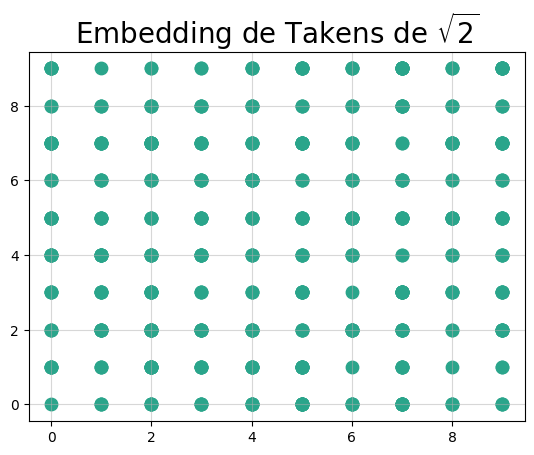

In [ ]:
plt.figure()
plt.scatter(embeddings_takens[0][:,0],embeddings_takens[0][:,1], color='#2AA58B', s=80)
plt.title(r"Embedding de Takens de $\sqrt{2}$", fontsize=20)
plt.grid(True, alpha=0.5)
plt.savefig("Embedding de Takens de sqrt{2}.png", dpi=300, bbox_inches='tight')
plt.show()

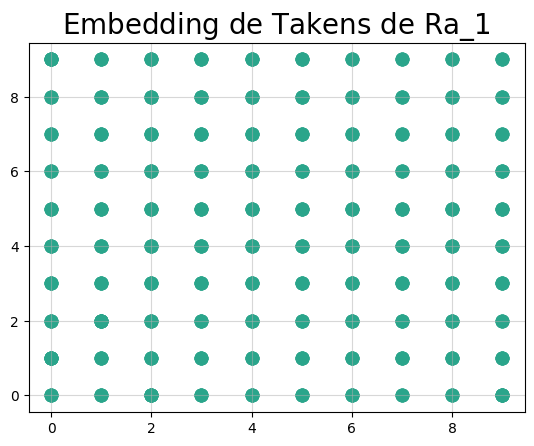

In [ ]:
plt.figure()
plt.scatter(embeddings_takens[8][:,0],embeddings_takens[8][:,1], color='#2AA58B', s=80)
plt.title(r"Embedding de Takens de $\text{Ra_1}$", fontsize=20)
plt.grid(True, alpha=0.5)
plt.savefig("Embedding de Takens de Ra_1.png", dpi=300, bbox_inches='tight')
plt.show()

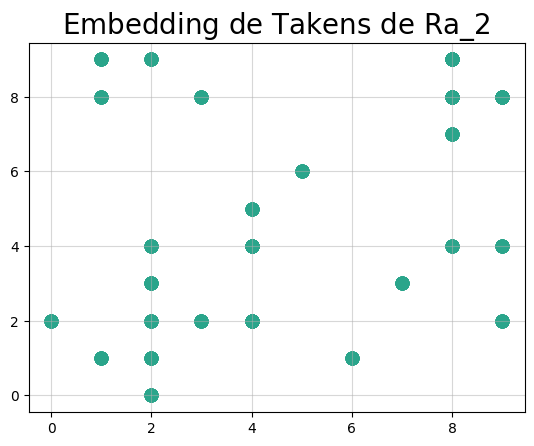

In [ ]:
plt.figure()
plt.scatter(embeddings_takens[9][:,0],embeddings_takens[9][:,1], color='#2AA58B', s=80)
plt.title(r"Embedding de Takens de $\text{Ra_2}$", fontsize=20)
plt.grid(True, alpha=0.5)
plt.savefig("Embedding de Takens de Ra_2.png", dpi=300, bbox_inches='tight')
plt.show()

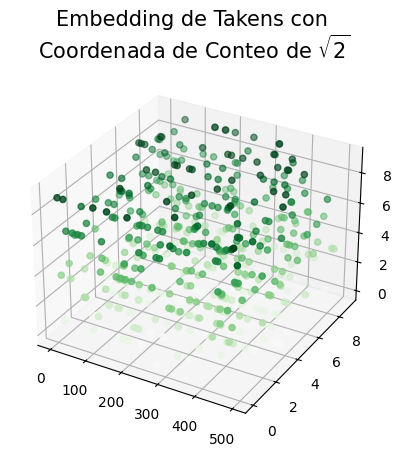

In [ ]:
fig = plt.figure( )
ax = plt.axes(projection='3d')
ax.scatter3D (puntos[0][:,0],  puntos[0][:,1],  puntos[0][:,2],  c=puntos[0][:,2], cmap = 'Greens')
plt.title("Embedding de Takens con \n"+r"Coordenada de Conteo de $\sqrt{2}$", fontsize=15)
plt.savefig("Embedding de Takens con Coordenada de Conteo de sqrt{2}.png", dpi=300, bbox_inches='tight')


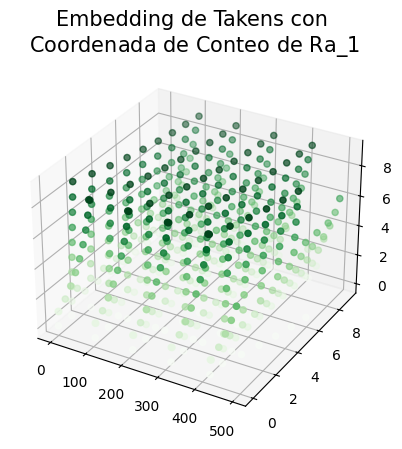

In [ ]:
fig = plt.figure( )
ax = plt.axes(projection='3d')
ax.scatter3D (puntos[8][:,0],  puntos[8][:,1],  puntos[8][:,2],  c=puntos[8][:,2], cmap = 'Greens')
plt.title("Embedding de Takens con \n"+r"Coordenada de Conteo de $\text{Ra_1}$", fontsize=15)
plt.savefig("Embedding de Takens con Coordenada de Conteo de Ra_1.png", dpi=300, bbox_inches='tight')

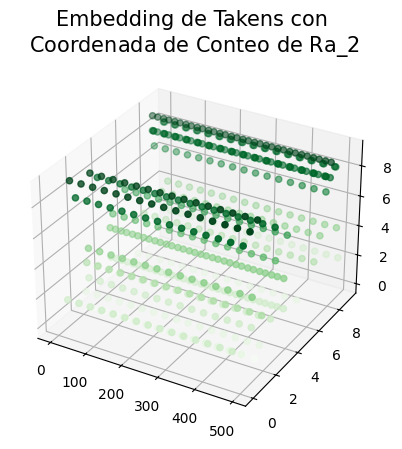

In [ ]:
fig = plt.figure( )
ax = plt.axes(projection='3d')
ax.scatter3D (puntos[9][:,0],  puntos[9][:,1],  puntos[9][:,2],  c=puntos[9][:,2], cmap = 'Greens')
plt.title("Embedding de Takens con \n"+r"Coordenada de Conteo de $\text{Ra_2}$", fontsize=15)
plt.savefig("Embedding de Takens con Coordenada de Conteo de Ra_2.png", dpi=300, bbox_inches='tight')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_71444/3812429717.py:1: SyntaxWarning: invalid escape sequence '\s'
  graficar_diag(diagramas_persistencia[0], Titulo=r'Diagrama de Persistencia $\sqrt{2}$', guardado='Diagrama de Persistencia \sqrt{2}')


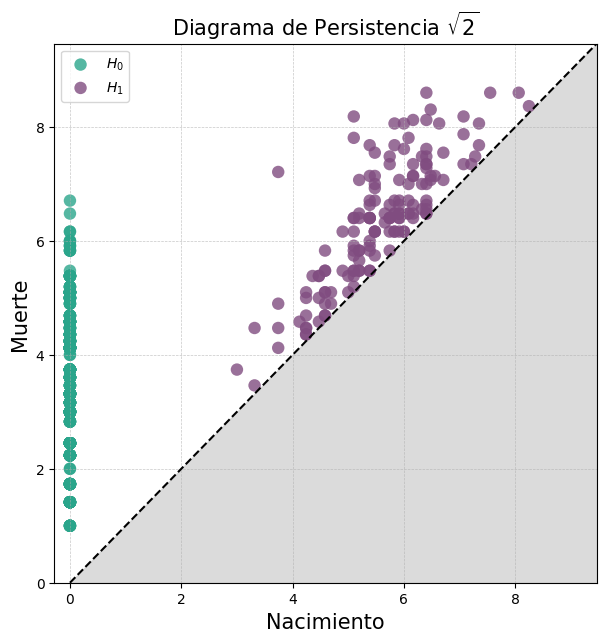

In [ ]:
graficar_diag(diagramas_persistencia[0], Titulo=r'Diagrama de Persistencia $\sqrt{2}$', guardado='Diagrama de Persistencia \sqrt{2}')

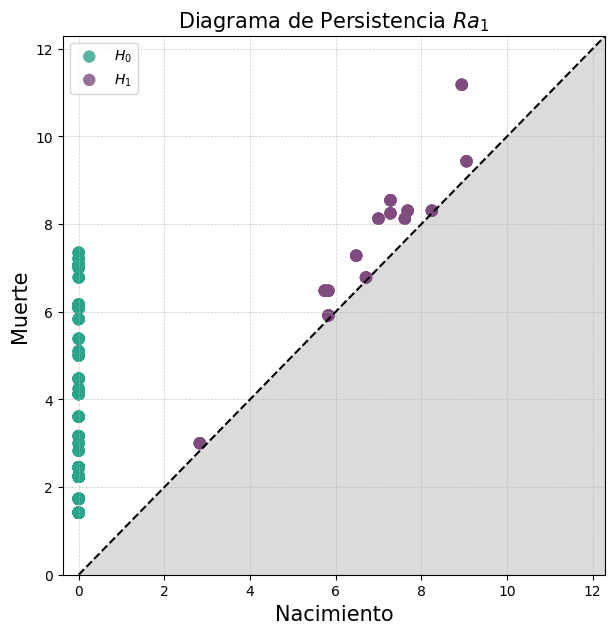

In [ ]:
graficar_diag(diagramas_persistencia[8], Titulo=r'Diagrama de Persistencia $Ra_1$', guardado=r'Diagrama de Persistencia Ra_1')

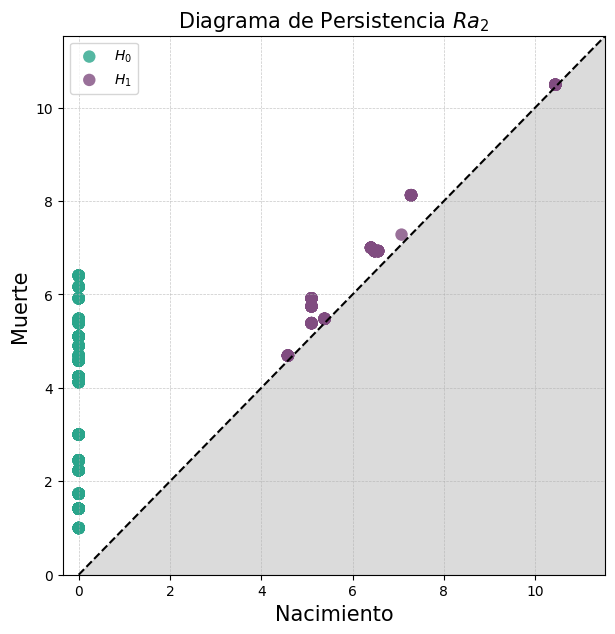

In [ ]:
graficar_diag(diagramas_persistencia[9], Titulo=r'Diagrama de Persistencia $Ra_2$', guardado=r'Diagrama de Persistencia Ra_2')

# **Concatenación**

In [ ]:
#Calcular vectorización mediante concatenación
concatenacion_planos=[]
for j in range(len(Datos)):
  if diagramas_persistencia[j][1].tolist()!=[]:
    concatenacion_planos.append(diagramas_persistencia[j][1].flatten())
  else:
    concatenacion_planos.append([])


In [ ]:
#Aplicar Padding
dimensiones_concatenacion=[]
for j in range(len(Datos)):
  dimensiones_concatenacion.append(len(concatenacion_planos[j]))

concatenacion_planos_padding=[]

for j in range(len(Datos)):
  ceros=np.zeros(max(dimensiones_concatenacion)-len(concatenacion_planos[j]))
  concatenacion_planos_padding.append(np.concatenate((concatenacion_planos[j], ceros)))

In [ ]:
#Coeficiente de silueta natural
score = silhouette_score(concatenacion_planos_padding, etiquetas)
print(f"Coeficiente de silueta natural: {score}")

Coeficiente de silueta natural: -0.06525974921899007


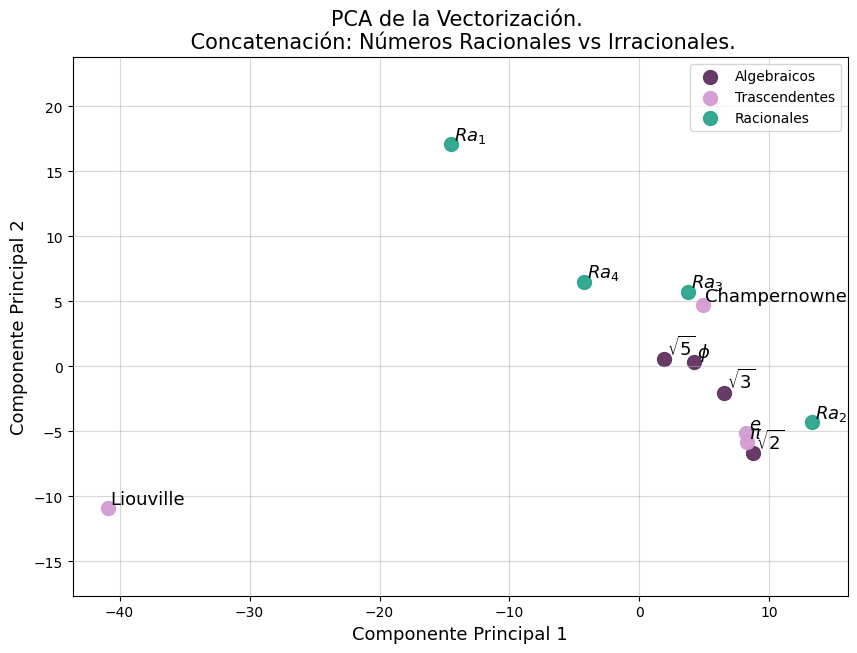

In [ ]:
#Aplicar PCA de dimensión dos para visualizar los datos
pca=PCA(n_components=2)

X_scaled = StandardScaler().fit_transform(concatenacion_planos_padding)

concatenacion_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for i in range(3):
    inicio, fin = i*4, (i+1)*4
    plt.scatter(concatenacion_pca[:,0][inicio:fin], concatenacion_pca[:,1][inicio:fin], c=colores[i], label=tipo_numero[i], s=100, alpha=0.95)

for i in range(len(concatenacion_pca[:,0])):
    plt.annotate(nombres[i], (concatenacion_pca[:,0][i], concatenacion_pca[:,1][i]), xytext=(2, 3), textcoords="offset points", ha='left',fontsize=13)

plt.title(f"PCA de la Vectorización. \n Concatenación: {titulo}.", fontsize=15)
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlabel(r"Componente Principal 1", fontsize=13)
plt.ylabel(r"Componente Principal 2", fontsize=13)
plt.savefig(f"PCA_Concatenacion_{titulo}.png", dpi=300, bbox_inches='tight')
plt.axis('equal')
plt.show()

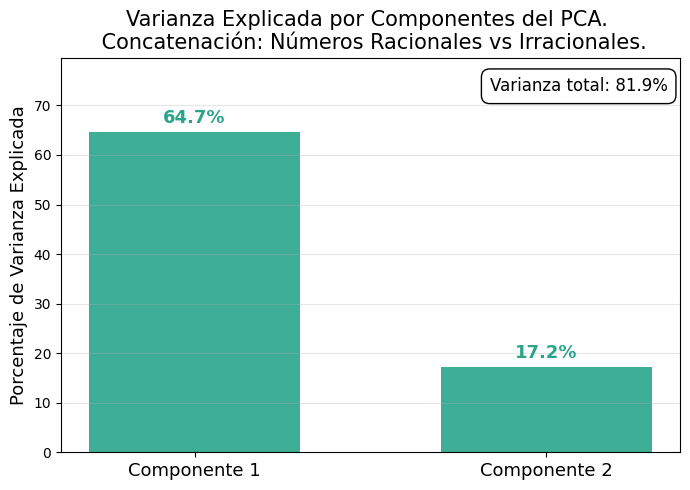

In [ ]:
# Varianza explicada del PCA
varianza_explicada = pca.explained_variance_ratio_
varianza_total = sum(varianza_explicada) * 100

plt.figure(figsize=(7, 5))

x = [1, 2]
y = varianza_explicada * 100
bars = plt.bar(x, y, alpha=0.9, color='#2AA58B', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=13, color="#2AA58B", fontweight='bold')

plt.xticks([1, 2], ['Componente 1', 'Componente 2'], fontsize=13)
plt.ylabel('Porcentaje de Varianza Explicada', fontsize=13)
plt.title(f'Varianza Explicada por Componentes del PCA. \n Concatenación: {titulo}.', fontsize=15)
plt.grid(axis='y', alpha=0.3)

plt.text(0.98, 0.95, f'Varianza total: {varianza_total:.1f}%',
         transform=plt.gca().transAxes,
         ha='right', va='top',
         fontsize=12,
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.5'))

plt.ylim(0, max(y) + 15)
plt.tight_layout()
plt.savefig(f"Varianza Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

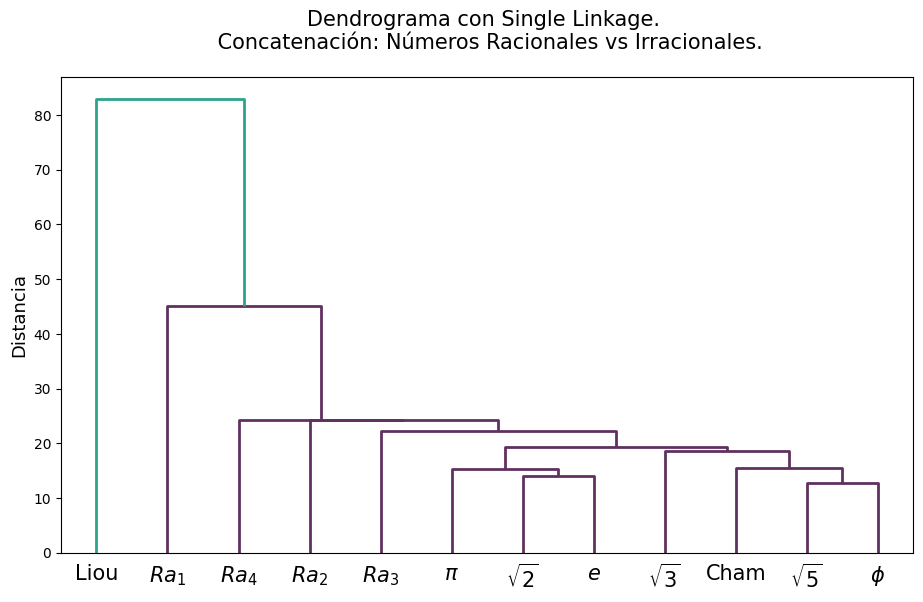

In [ ]:
#Calcular el dendrograma single linkage de la vectorización
Z_S = linkage(concatenacion_planos_padding, method='single', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(11, 7))

umbral_manual = 80
color_final = colores[2]

dendro = dendrogram(Z_S, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -2

nombres_dendo = [r'$\sqrt{2}$', r'$\sqrt{3}$', r'$\sqrt{5}$', r'$\phi$', r'$\pi$', r'$e$', 'Cham', 'Liou', r'$Ra_1$', r'$Ra_2$', r'$Ra_3$', r'$Ra_4$']
nombres_a_rotar = {'Liou', 'Cham'}

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres_dendo[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Single Linkage. \n Concatenación: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Single Linkage Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

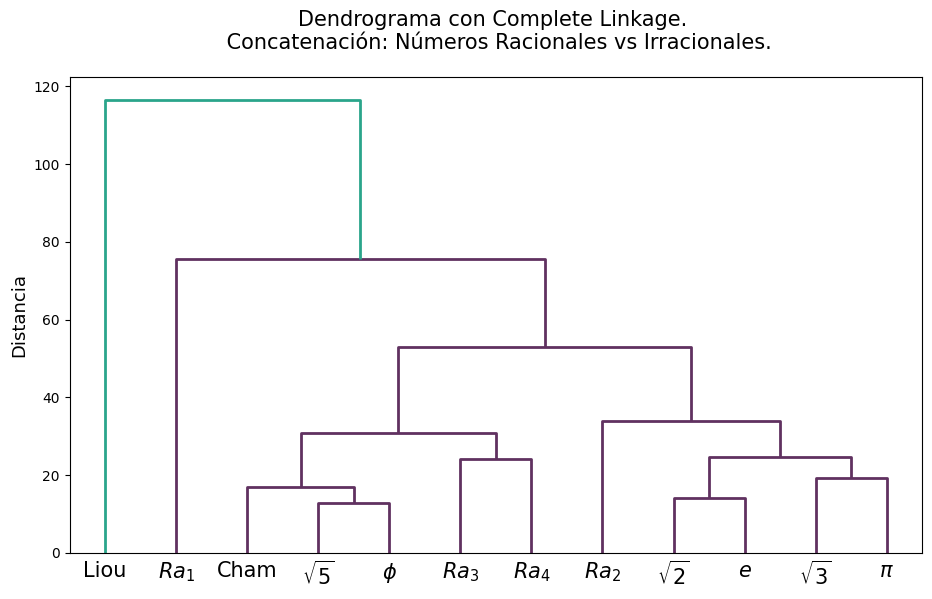

In [ ]:
#Calcular el dendrograma complete linkage de la vectorización
Z_C = linkage(concatenacion_planos_padding, method='complete', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 80
color_final = colores[2]

dendro = dendrogram(Z_C, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -2

nombres_dendo = [r'$\sqrt{2}$', r'$\sqrt{3}$', r'$\sqrt{5}$', r'$\phi$', r'$\pi$', r'$e$', 'Cham', 'Liou', r'$Ra_1$', r'$Ra_2$', r'$Ra_3$', r'$Ra_4$']
nombres_a_rotar = {'Liou', 'Cham'}

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres_dendo[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Complete Linkage. \n Concatenación: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Complete Linkage Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

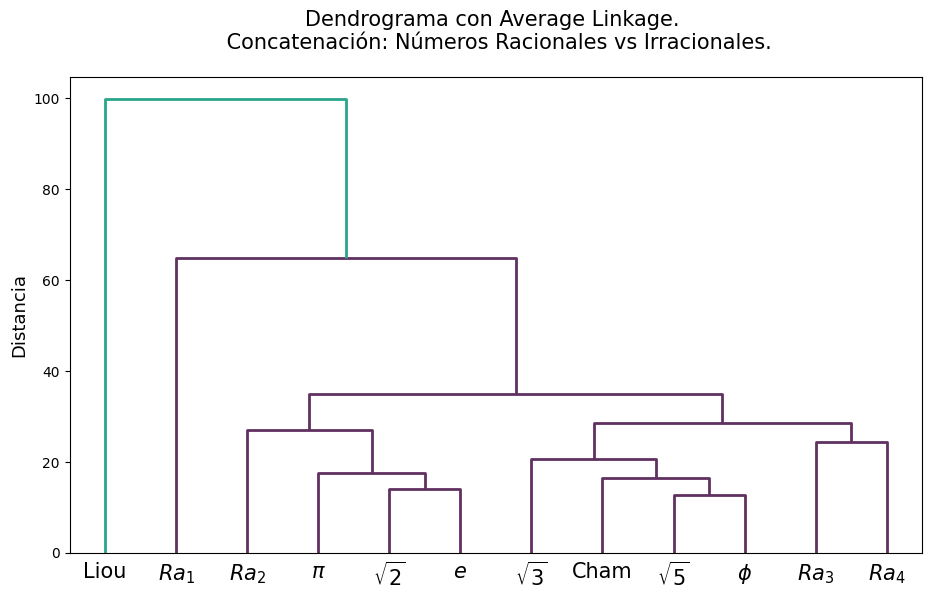

In [ ]:
#Calcular el dendrograma average linkage de la vectorización
Z_A = linkage(concatenacion_planos_padding, method='average', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 80
color_final = colores[2]

dendro = dendrogram(Z_A, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -2

nombres_dendo = [r'$\sqrt{2}$', r'$\sqrt{3}$', r'$\sqrt{5}$', r'$\phi$', r'$\pi$', r'$e$', 'Cham', 'Liou', r'$Ra_1$', r'$Ra_2$', r'$Ra_3$', r'$Ra_4$']
nombres_a_rotar = {'Liou', 'Cham'}

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres_dendo[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Average Linkage. \n Concatenación: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Average Linkage Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

# **Landscapes**

In [ ]:
#Calcular vectorización mediante landscapes
landscapes=[]

for j in range(len(Datos)):
    aux=diagramas_persistencia[j][1].tolist()

    if aux!=[]:
      landscapes.append(persistence_landscape(aux))
    else:
      landscapes.append([])

In [ ]:
#Aplanar landscapes
landscapes_planos=[]
for j in range(len(Datos)):

  if landscapes[j]!=[]:
    aux=landscapes[j][0]
    for i in range(1,len(landscapes[j])):
      aux=np.concatenate((aux, landscapes[j][i]))

    aux=[p for p in aux if not math.isinf(p[0])]
    landscapes_planos.append(aux)
  else:
    landscapes_planos.append((0,0))

  landscapes_planos[j]=np.array(landscapes_planos[j]).flatten()

In [ ]:
#Aplicar Padding
dimensiones=[]
for j in range(len(Datos)):
  dimensiones.append(len(landscapes_planos[j]))

landscapes_planos_padding=[]

for j in range(len(Datos)):
  ceros=np.zeros(max(dimensiones)-len(landscapes_planos[j]))
  landscapes_planos_padding.append(np.concatenate((landscapes_planos[j], ceros)))

In [ ]:
#Coeficiente de silueta natural
score = silhouette_score(landscapes_planos_padding, etiquetas)
print(f"Coeficiente de silueta natural: {score}")

Coeficiente de silueta natural: 0.13027140880317903


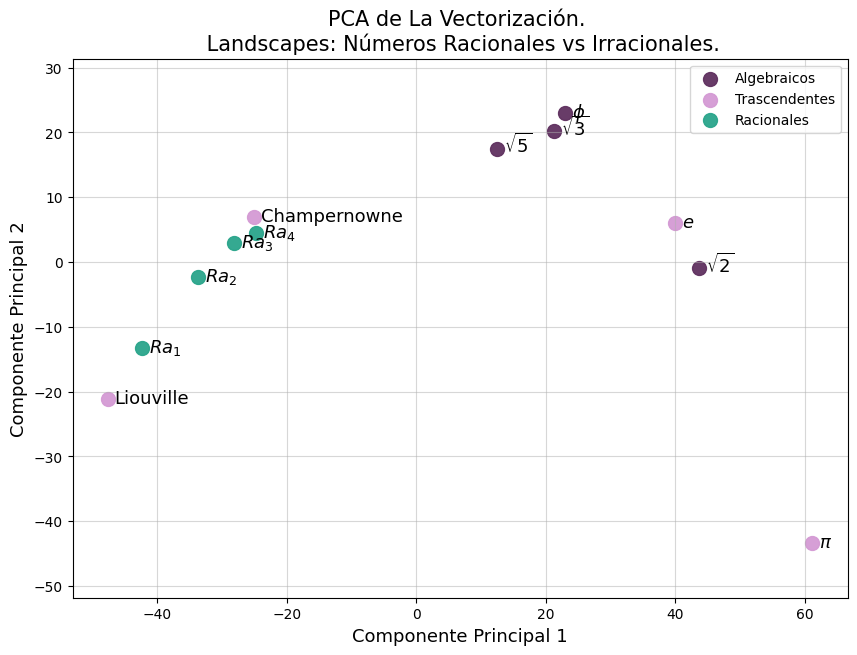

In [ ]:
#Aplicar PCA de dimensión dos para visualizar los datos
pca=PCA(n_components=2)

X_scaled = StandardScaler().fit_transform(landscapes_planos_padding)

landscapes_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for i in range(3):
    inicio, fin = i*4, (i+1)*4
    plt.scatter(landscapes_pca[:,0][inicio:fin], landscapes_pca[:,1][inicio:fin], c=colores[i], label=tipo_numero[i], s=100, alpha=0.95)

for i in range(len(landscapes_pca[:,0])):
    plt.annotate(nombres[i], (landscapes_pca[:,0][i], landscapes_pca[:,1][i]), xytext=(5, -3), textcoords="offset points", ha='left',fontsize=13)

plt.title(f"PCA de La Vectorización. \n Landscapes: {titulo}.", fontsize=15)
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlabel(r"Componente Principal 1", fontsize=13)
plt.ylabel(r"Componente Principal 2", fontsize=13)
plt.savefig(f"PCA_Landscapes_{titulo}.png", dpi=300, bbox_inches='tight')
plt.axis('equal')
plt.show()

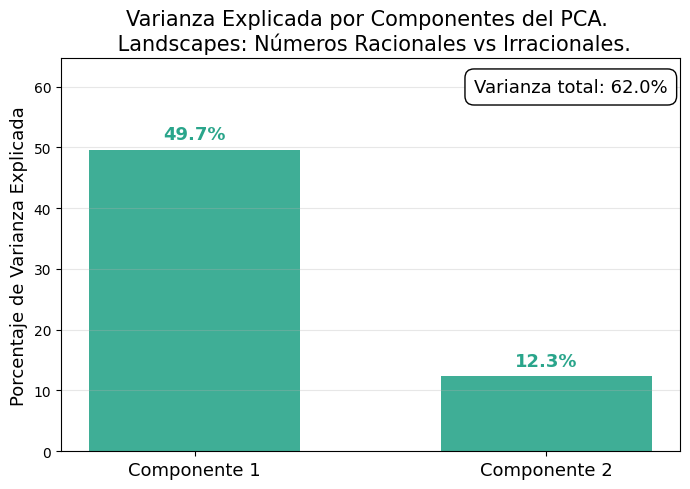

In [ ]:
# Varianza explicada del PCA
varianza_explicada = pca.explained_variance_ratio_
varianza_total = sum(varianza_explicada) * 100

plt.figure(figsize=(7, 5))

x = [1, 2]
y = varianza_explicada * 100
bars = plt.bar(x, y, alpha=0.9, color='#2AA58B', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=13, color="#2AA58B", fontweight='bold')

plt.xticks([1, 2], ['Componente 1', 'Componente 2'], fontsize=13)
plt.ylabel('Porcentaje de Varianza Explicada', fontsize=13)
plt.title(f'Varianza Explicada por Componentes del PCA. \n Landscapes: {titulo}.', fontsize=15)
plt.grid(axis='y', alpha=0.3)

plt.text(0.98, 0.95, f'Varianza total: {varianza_total:.1f}%',
         transform=plt.gca().transAxes,
         ha='right', va='top',
         fontsize=13,
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.5'))


plt.ylim(0, max(y) + 15)
plt.tight_layout()
plt.savefig(f"Varianza Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

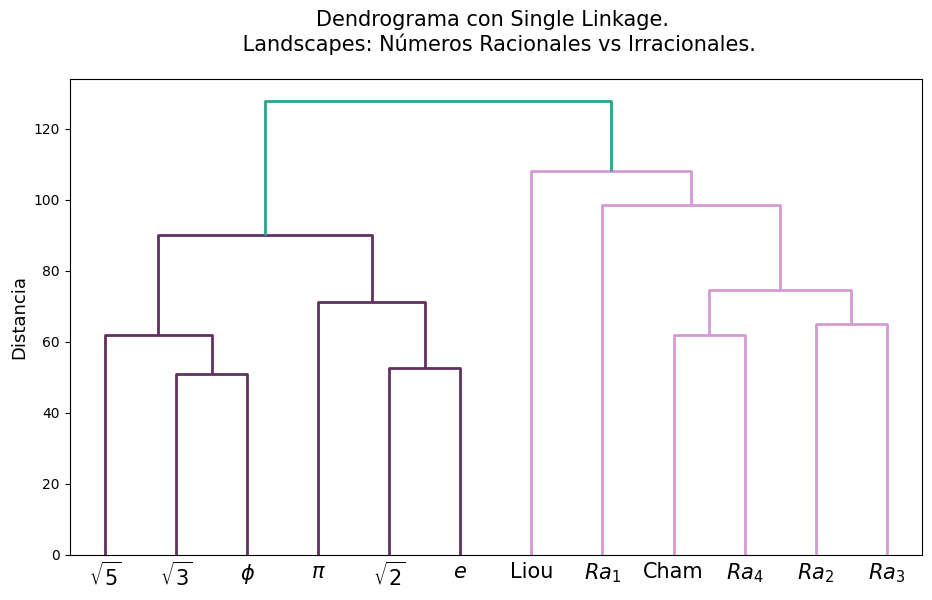

In [ ]:
#Calcular el dendrograma single linkage de la vectorización
Z_S = linkage(landscapes_planos_padding, method='single', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 120
color_final = colores[2]

dendro = dendrogram(Z_S, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -2

nombres_dendo = [r'$\sqrt{2}$', r'$\sqrt{3}$', r'$\sqrt{5}$', r'$\phi$', r'$\pi$', r'$e$', 'Cham', 'Liou', r'$Ra_1$', r'$Ra_2$', r'$Ra_3$', r'$Ra_4$']
nombres_a_rotar = {'Liou', 'Cham'}

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres_dendo[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Single Linkage. \n Landscapes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Single Linkage Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

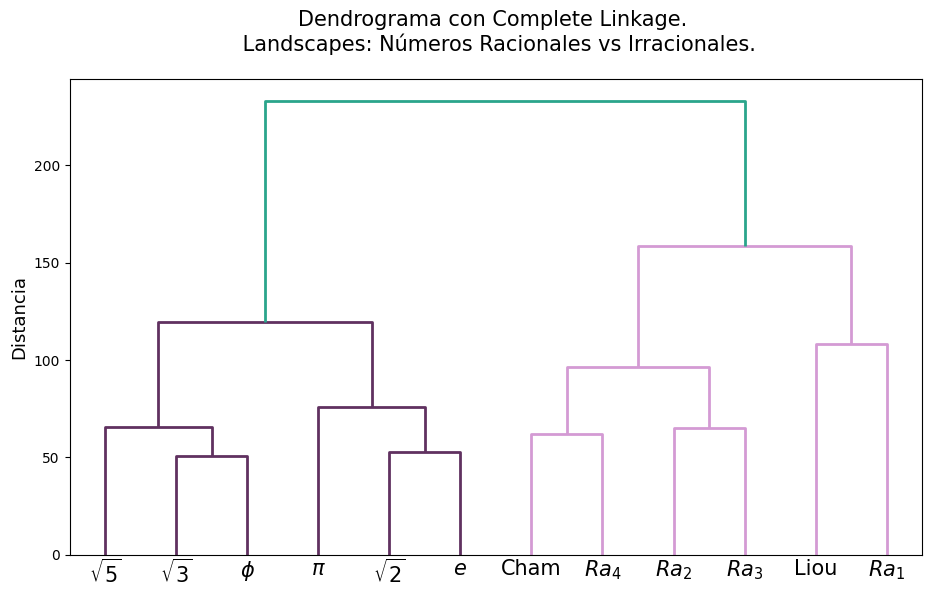

In [ ]:
#Calcular el dendrograma complete linkage de la vectorización
Z_C = linkage(landscapes_planos_padding, method='complete', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 200
color_final = colores[2]

dendro = dendrogram(Z_C, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -2

nombres_dendo = [r'$\sqrt{2}$', r'$\sqrt{3}$', r'$\sqrt{5}$', r'$\phi$', r'$\pi$', r'$e$', 'Cham', 'Liou', r'$Ra_1$', r'$Ra_2$', r'$Ra_3$', r'$Ra_4$']
nombres_a_rotar = {'Liou', 'Cham'}

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres_dendo[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Complete Linkage. \n Landscapes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Complete Linkage Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

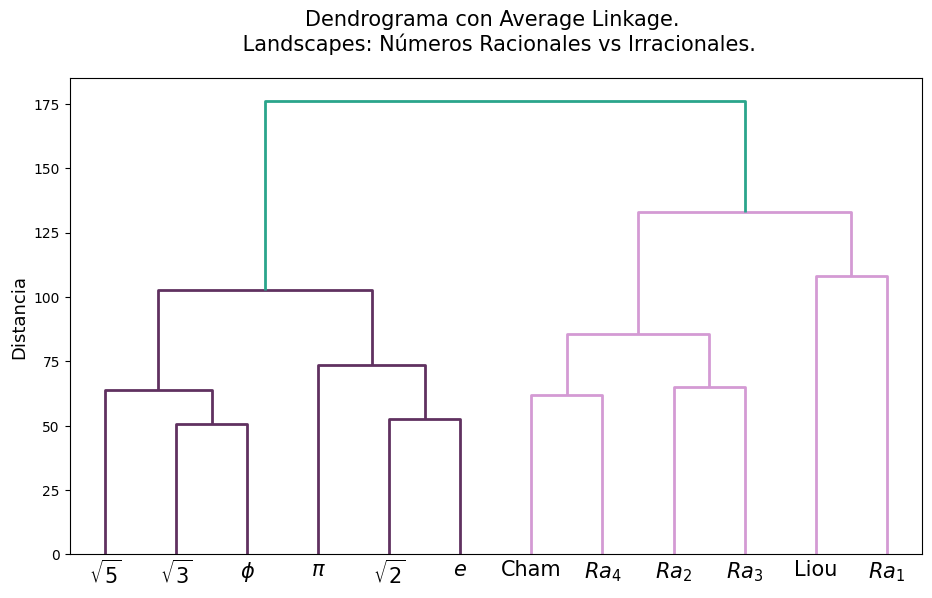

In [ ]:
#Calcular el dendrograma average linkage de la vectorización
Z_A = linkage(landscapes_planos_padding, method='average', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 150
color_final = colores[2]

dendro = dendrogram(Z_A, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -2

nombres_dendo = [r'$\sqrt{2}$', r'$\sqrt{3}$', r'$\sqrt{5}$', r'$\phi$', r'$\pi$', r'$e$', 'Cham', 'Liou', r'$Ra_1$', r'$Ra_2$', r'$Ra_3$', r'$Ra_4$']
nombres_a_rotar = {'Liou', 'Cham'}

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres_dendo[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Average Linkage. \n Landscapes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Average Linkage Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

# **Imagenes Persistentes**

In [ ]:
#Calcular vectorización mediante imágenes persistentes
imagenes_persistencia=[]
for j in range(0,len(Datos)):
    pimgr = PersistenceImager()
    pimgr.birth_range = (0, 12)
    pimgr.pers_range = (0, 10)
    pimgr.kernel_params = {'sigma': 5.0}
    imagenes_persistencia.append(pimgr.transform(diagramas_persistencia[j][1]))


In [ ]:
#Aplanar imágenes persistentes
imagenes_planas=[]
for j in range(0,len(Datos)):
  imagenes_planas.append(imagenes_persistencia[j].flatten())

imagenes_planas=np.array(imagenes_planas)

In [ ]:
#Coeficiente de silueta natural
score = silhouette_score(imagenes_planas, etiquetas)
print(f"Coeficiente de silueta natural: {score}")

Coeficiente de silueta natural: 0.013579423132227847


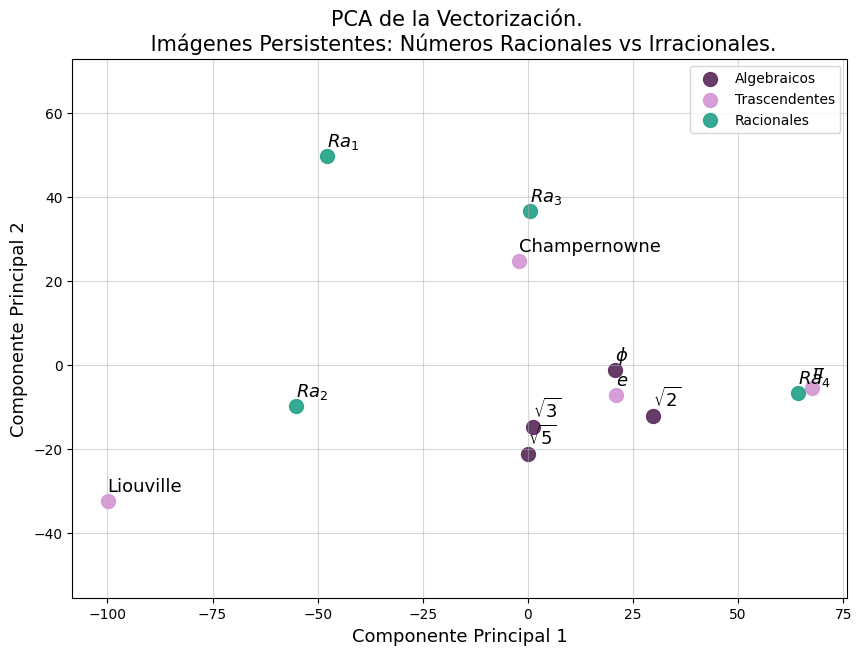

In [ ]:
#Aplicar PCA de dimensión dos para visualizar los datos
pca=PCA(n_components=2)

X_scaled = StandardScaler().fit_transform(imagenes_planas)

imagenes_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for i in range(3):
    inicio, fin = i*4, (i+1)*4
    plt.scatter(imagenes_pca[:,0][inicio:fin], imagenes_pca[:,1][inicio:fin], c=colores[i], label=tipo_numero[i], s=100, alpha=0.95)

for i in range(len(imagenes_pca[:,0])):
    plt.annotate(nombres[i], (imagenes_pca[:,0][i], imagenes_pca[:,1][i]), xytext=(0, 7), textcoords="offset points", ha='left',fontsize=13)


plt.title(f"PCA de la Vectorización. \n Imágenes Persistentes: {titulo}.", fontsize=15)
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlabel(r"Componente Principal 1", fontsize=13)
plt.ylabel(r"Componente Principal 2", fontsize=13)
plt.savefig(f"PCA_Imagenes_Persistentes_{titulo}.png", dpi=300, bbox_inches='tight')
plt.axis('equal')
plt.show()

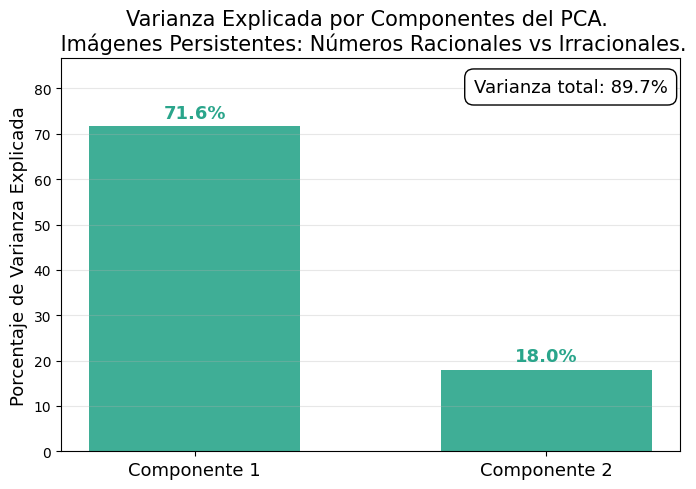

In [ ]:
# Varianza explicada del PCA
varianza_explicada = pca.explained_variance_ratio_
varianza_total = sum(varianza_explicada) * 100

plt.figure(figsize=(7, 5))
x = [1, 2]
y = varianza_explicada * 100
bars = plt.bar(x, y, alpha=0.9, color='#2AA58B', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=13, color="#2AA58B", fontweight='bold')

plt.xticks([1, 2], ['Componente 1', 'Componente 2'], fontsize=13)
plt.ylabel('Porcentaje de Varianza Explicada', fontsize=13)
plt.title(f'Varianza Explicada por Componentes del PCA. \n Imágenes Persistentes: {titulo}.', fontsize=15)
plt.grid(axis='y', alpha=0.3)

plt.text(0.98, 0.95, f'Varianza total: {varianza_total:.1f}%',
         transform=plt.gca().transAxes,
         ha='right', va='top',
         fontsize=13,
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.5'))


plt.ylim(0, max(y) + 15)
plt.tight_layout()
plt.savefig(f"Varianza Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

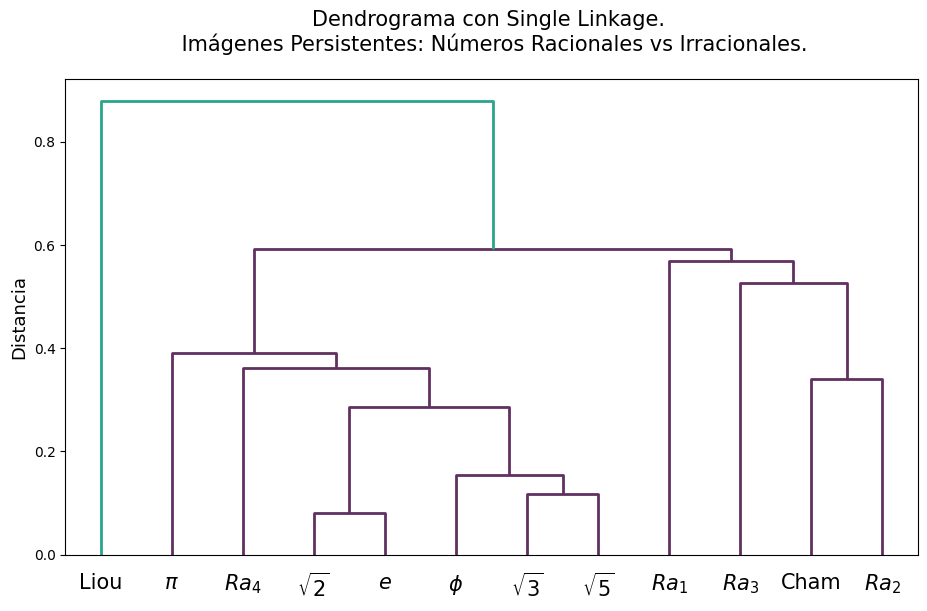

In [ ]:
#Calcular el dendrograma single linkage de la vectorización
Z_S = linkage(imagenes_planas, method='single', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 0.7
color_final = colores[2]

dendro = dendrogram(Z_S, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.035

nombres_dendo = [r'$\sqrt{2}$', r'$\sqrt{3}$', r'$\sqrt{5}$', r'$\phi$', r'$\pi$', r'$e$', 'Cham', 'Liou', r'$Ra_1$', r'$Ra_2$', r'$Ra_3$', r'$Ra_4$']
nombres_a_rotar = {'Liou', 'Cham'}

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres_dendo[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Single Linkage. \n Imágenes Persistentes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Single Linkage Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

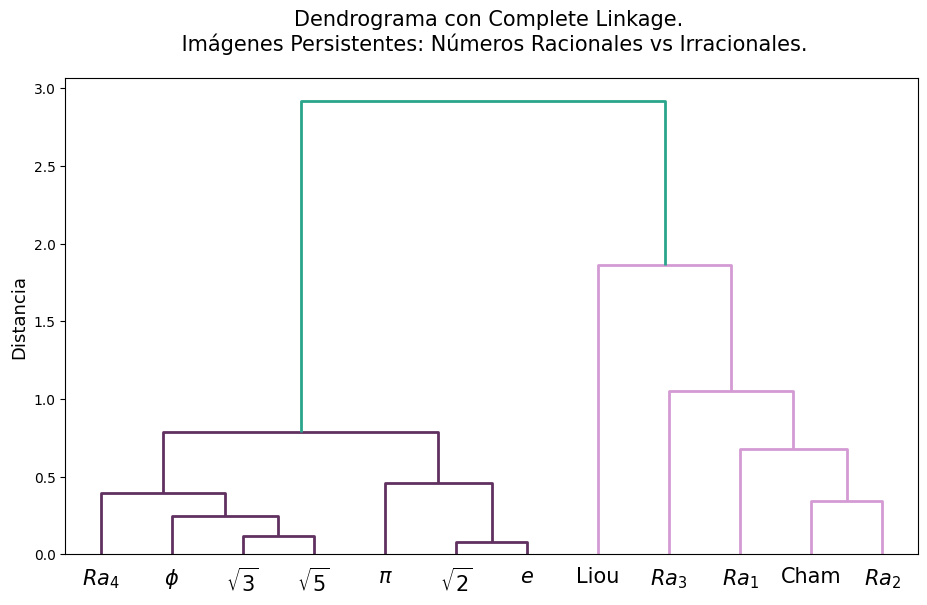

In [ ]:
#Calcular el dendrograma complete linkage de la vectorización
Z_C = linkage(imagenes_planas, method='complete', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 2.9
color_final = colores[2]

dendro = dendrogram(Z_C, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.08

nombres_dendo = [r'$\sqrt{2}$', r'$\sqrt{3}$', r'$\sqrt{5}$', r'$\phi$', r'$\pi$', r'$e$', 'Cham', 'Liou', r'$Ra_1$', r'$Ra_2$', r'$Ra_3$', r'$Ra_4$']
nombres_a_rotar = {'Liou', 'Cham'}

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres_dendo[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Complete Linkage. \n Imágenes Persistentes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Complete Linkage Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

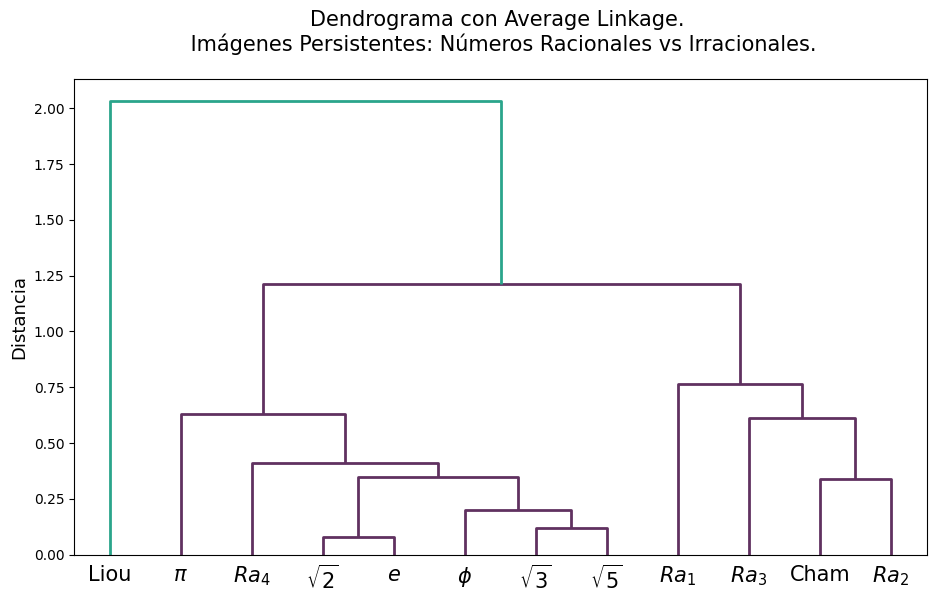

In [ ]:
#Calcular el dendrograma average linkage de la vectorización
Z_A = linkage(imagenes_planas, method='average', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 1.9
color_final = colores[2]

dendro = dendrogram(Z_A, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.045

nombres_dendo = [r'$\sqrt{2}$', r'$\sqrt{3}$', r'$\sqrt{5}$', r'$\phi$', r'$\pi$', r'$e$', 'Cham', 'Liou', r'$Ra_1$', r'$Ra_2$', r'$Ra_3$', r'$Ra_4$']
nombres_a_rotar = {'Liou', 'Cham'}

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres_dendo[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Average Linkage. \n Imágenes Persistentes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Average Linkage Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()